In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('emails.csv')
print(df.head())
print(df.shape)
print(df.columns)

                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1
(5728, 2)
Index(['text', 'spam'], dtype='str')


spam
0    4360
1    1368
Name: count, dtype: int64


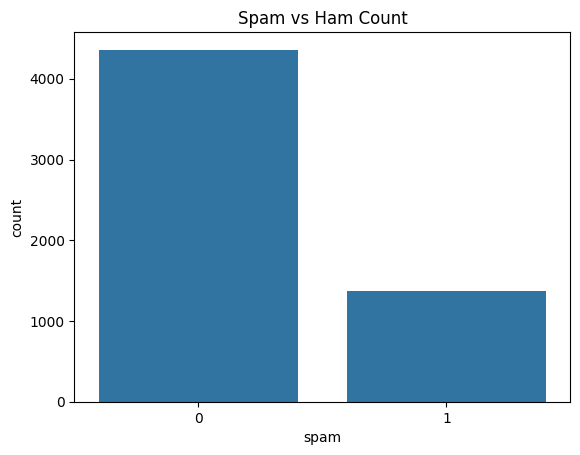

In [3]:
print(df['spam'].value_counts())
sns.countplot(x='spam', data=df)
plt.title('Spam vs Ham Count')
plt.show()

In [4]:
df = df.fillna('')
X = df['text']
y = df['spam']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training size:", len(X_train))
print("Testing size:", len(X_test))


Training size: 4582
Testing size: 1146


In [6]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print("Vectorizer Ready!")

Vectorizer Ready!


In [7]:

model = MultinomialNB()
model.fit(X_train_vec, y_train)
print("Model Trained Successfully!")

Model Trained Successfully!


In [8]:
y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9790575916230366
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       856
           1       0.97      0.94      0.96       290

    accuracy                           0.98      1146
   macro avg       0.98      0.97      0.97      1146
weighted avg       0.98      0.98      0.98      1146



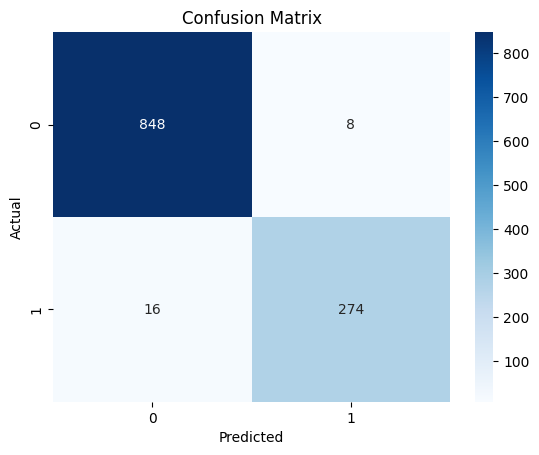

In [9]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [10]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.9790575916230366


In [11]:
print(df['spam'].value_counts())
print(df['spam'].dtype)

spam
0    4360
1    1368
Name: count, dtype: int64
int64


In [12]:
def predict_email(email):
    vec = vectorizer.transform([email])
    result = model.predict(vec)[0]
    if result == 1:
        print("🚨 We strongly advise you not to respond to this email!")
    else:
        print("✅ This email requires your attention!")

In [14]:
email = input("Enter email: ")
predict_email(email)

Enter email:  You have won a lottery of 1 million dollars, claim now!


🚨 We strongly advise you not to respond to this email!


In [15]:
email = input("Enter email: ")
predict_email(email)

Enter email:  Mom said dinner is ready, come home early today.


✅ This email requires your attention!


In [17]:
test_emails = [
    "You have won a lottery of 1 million dollars, claim now!",
    "Don't forget to bring your laptop to class tomorrow.",
    "Urgent! Your bank account has been suspended, verify now!",
    "The project deadline has been extended to next Monday.",
    "Win a free car! Click now!",
    "Mom said dinner is ready, come home early today.",
    "You have won a free gift card, claim your prize now!",
    "Library books are due for return this Friday."
]

for email in test_emails:
    print(f"Email: {email}")
    predict_email(email)
    print("---")

Email: You have won a lottery of 1 million dollars, claim now!
🚨 We strongly advise you not to respond to this email!
---
Email: Don't forget to bring your laptop to class tomorrow.
✅ This email requires your attention!
---
Email: Urgent! Your bank account has been suspended, verify now!
🚨 We strongly advise you not to respond to this email!
---
Email: The project deadline has been extended to next Monday.
✅ This email requires your attention!
---
Email: Win a free car! Click now!
🚨 We strongly advise you not to respond to this email!
---
Email: Mom said dinner is ready, come home early today.
✅ This email requires your attention!
---
Email: You have won a free gift card, claim your prize now!
🚨 We strongly advise you not to respond to this email!
---
Email: Library books are due for return this Friday.
✅ This email requires your attention!
---
